## Проект по теме "Прогнозирование наличия сердечно-сосудистых заболеваний на основе характеристик пациентов"

Датасет представляет собой .csv файл, содержащий следующие поля:

* id: идентификатор для каждого человека в наборе данных;
* age: возраст человека (в днях);
* gender: пол (1 для женщин, 2 для мужчин);
* height: рост в сантиметрах;
* weight: вес в килограммах;
* ap_hi: систолическое артериальное давление (измеряется в мм рт.ст.);
* ap_lo: диастолическое артериальное давление (измеряется в мм рт.ст.);
* cholesterol: уровень холестерина (1 – в норме, 2 – выше нормы, 3 –
значительно выше нормы);
* gluc: уровень глюкозы (1 – в норме, 2 – выше нормы, 3 – значительно выше
нормы);
* smoke: курит ли человек (0 – нет, 1 – да);
* alco: употребляет ли человек алкоголь (0 – нет, 1 – да);
* active: является ли человек физически активным (0 – нет, 1 – да);
* cardio: наличие сердечно-сосудистых заболеваний (0 – нет, 1 – да).

Задачей является построить модель, предсказывающую наличие сердечно-сосудистых заболеваний.
Вам необходимо реализовать все дальнейшие шаги, обучить модель и оценить её качество.

## Задание 1: загрузка файла и проверка пропущенных значений (5 баллов)

Откройте данные и изучите их: есть ли пропущенные значения? Прокомментируйте результат. Если пропущенные значения есть - удалите строки с ними.

In [29]:
import numpy as np #для матричных вычислений
import pandas as pd #для анализа и предобработки данных
import matplotlib.pyplot as plt #для визуализации
import seaborn as sns #для визуализации


from sklearn import linear_model #линейные модели
from sklearn import metrics #метрики
from sklearn import preprocessing #предобработка
from sklearn.model_selection import train_test_split #разделение выборки
from sklearn import ensemble #ансамблевые методы

# ваш код
cvd = pd.read_csv('/Users/konstantingeneralov/IDE/Data/cvd.csv', sep=';')
cvd_1 = cvd.copy()

#проверим наличие дубликатов
duplicate_rows = cvd_1.duplicated().sum()
print("Количество дубликатов в данных:", duplicate_rows)
# проверим наличие пропущенных значений и уникальных значений в каждом столбце
summary = pd.DataFrame({
    "missing": cvd_1.isnull().sum(),
    "unique": cvd_1.nunique(),
    "dtype": cvd_1.dtypes
})
display(summary)

# дропнем столбец id, так как он не несет полезной информации для модели
cvd_1.drop('id', axis=1, inplace=True) 

display(cvd_1.head(), cvd_1.info(), cvd_1.describe())


Количество дубликатов в данных: 0


,missing,unique,dtype
id,0,70000,int64
age,0,8076,int64
gender,0,2,int64
height,0,109,int64
weight,0,287,float64
ap_hi,0,153,int64
ap_lo,0,157,int64
cholesterol,0,3,int64
gluc,0,3,int64
smoke,0,2,int64


<class 'pandas.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   age          70000 non-null  int64  
 1   gender       70000 non-null  int64  
 2   height       70000 non-null  int64  
 3   weight       70000 non-null  float64
 4   ap_hi        70000 non-null  int64  
 5   ap_lo        70000 non-null  int64  
 6   cholesterol  70000 non-null  int64  
 7   gluc         70000 non-null  int64  
 8   smoke        70000 non-null  int64  
 9   alco         70000 non-null  int64  
 10  active       70000 non-null  int64  
 11  cardio       70000 non-null  int64  
dtypes: float64(1), int64(11)
memory usage: 6.4 MB


,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,17474,1,156,56.0,100,60,1,1,0,0,0,0


None

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,19468.865814,1.349571,164.359229,74.205690,128.817286,96.630414,1.366871,1.226457,0.088129,0.053771,0.803729,0.499700
std,2467.251667,0.476838,8.210126,14.395757,154.011419,188.472530,0.680250,0.572270,0.283484,0.225568,0.397179,0.500003
min,10798.000000,1.000000,55.000000,10.000000,-150.000000,-70.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,17664.000000,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,19703.000000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
75%,21327.000000,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,23713.000000,2.000000,250.000000,200.000000,16020.000000,11000.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
# выводы: 
# На анализ предоставлен датасет о сердечно-сосудистых заболеваниях (CVD), который содержит 11 признаков и 1 целевую переменную 'cardio'.
# Проведенный анализ показал, что в данных нет дубликатов и пропущенных значений, а также что целевая переменная 'cardio' имеет 2 уникальных значения,
# что указывает на задачу классификации.
# имеется столбец 'id', который не несет полезной информации для модели и может быть удален.
# Есть 6 категориальных признаков (gender, cholesterol, gluc, smoke, alco, active) и 5 числовых признака (age, height, weight, ap_hi, ap_lo), 
# что может потребовать различной предобработки перед обучением модели. 
# ap_hi ap_lo показывает артериальное давление, что может быть важным для предсказания сердечно-сосудистых заболеваний.
 

## Задание 2: проверка данных на мультиколлинеарность (15 баллов)

**2.1** Данные обязательно необходимо проверить на мультиколлинеарность: линейную взаимосвязь между признаками. Сначала проверим наличие чистой мультиколлинеарности. Для того, чтобы её идентифицировать - для начала посчитайте ранг для матрицы корреляций и ее определитель. Какой вывод можно сделать?

In [30]:
# Проверяем на мультиколлинеарность: линейную взаимосвязь между признаками. 
corr_matrix = cvd_1.corr()
rank = np.linalg.matrix_rank(corr_matrix)
det = np.linalg.det(corr_matrix)
print("Ранг матрицы корреляций:", rank)
print("Определитель матрицы корреляций:", det)

Ранг матрицы корреляций: 12
Определитель матрицы корреляций: 0.34680717001985695


In [ ]:
# Выводы:
# Ранг матрицы корреляций равен количеству признаков, что указывает на отсутствие линейной зависимости между ними.
# Определитель матрицы корреляций не равен нулю, что также подтверждает отсутствие мультиколлинеарности в данных.

**2.2** Теперь проверьте мультиколлинеарность с помощью матрицы корреляций. Какие выводы можно сделать?

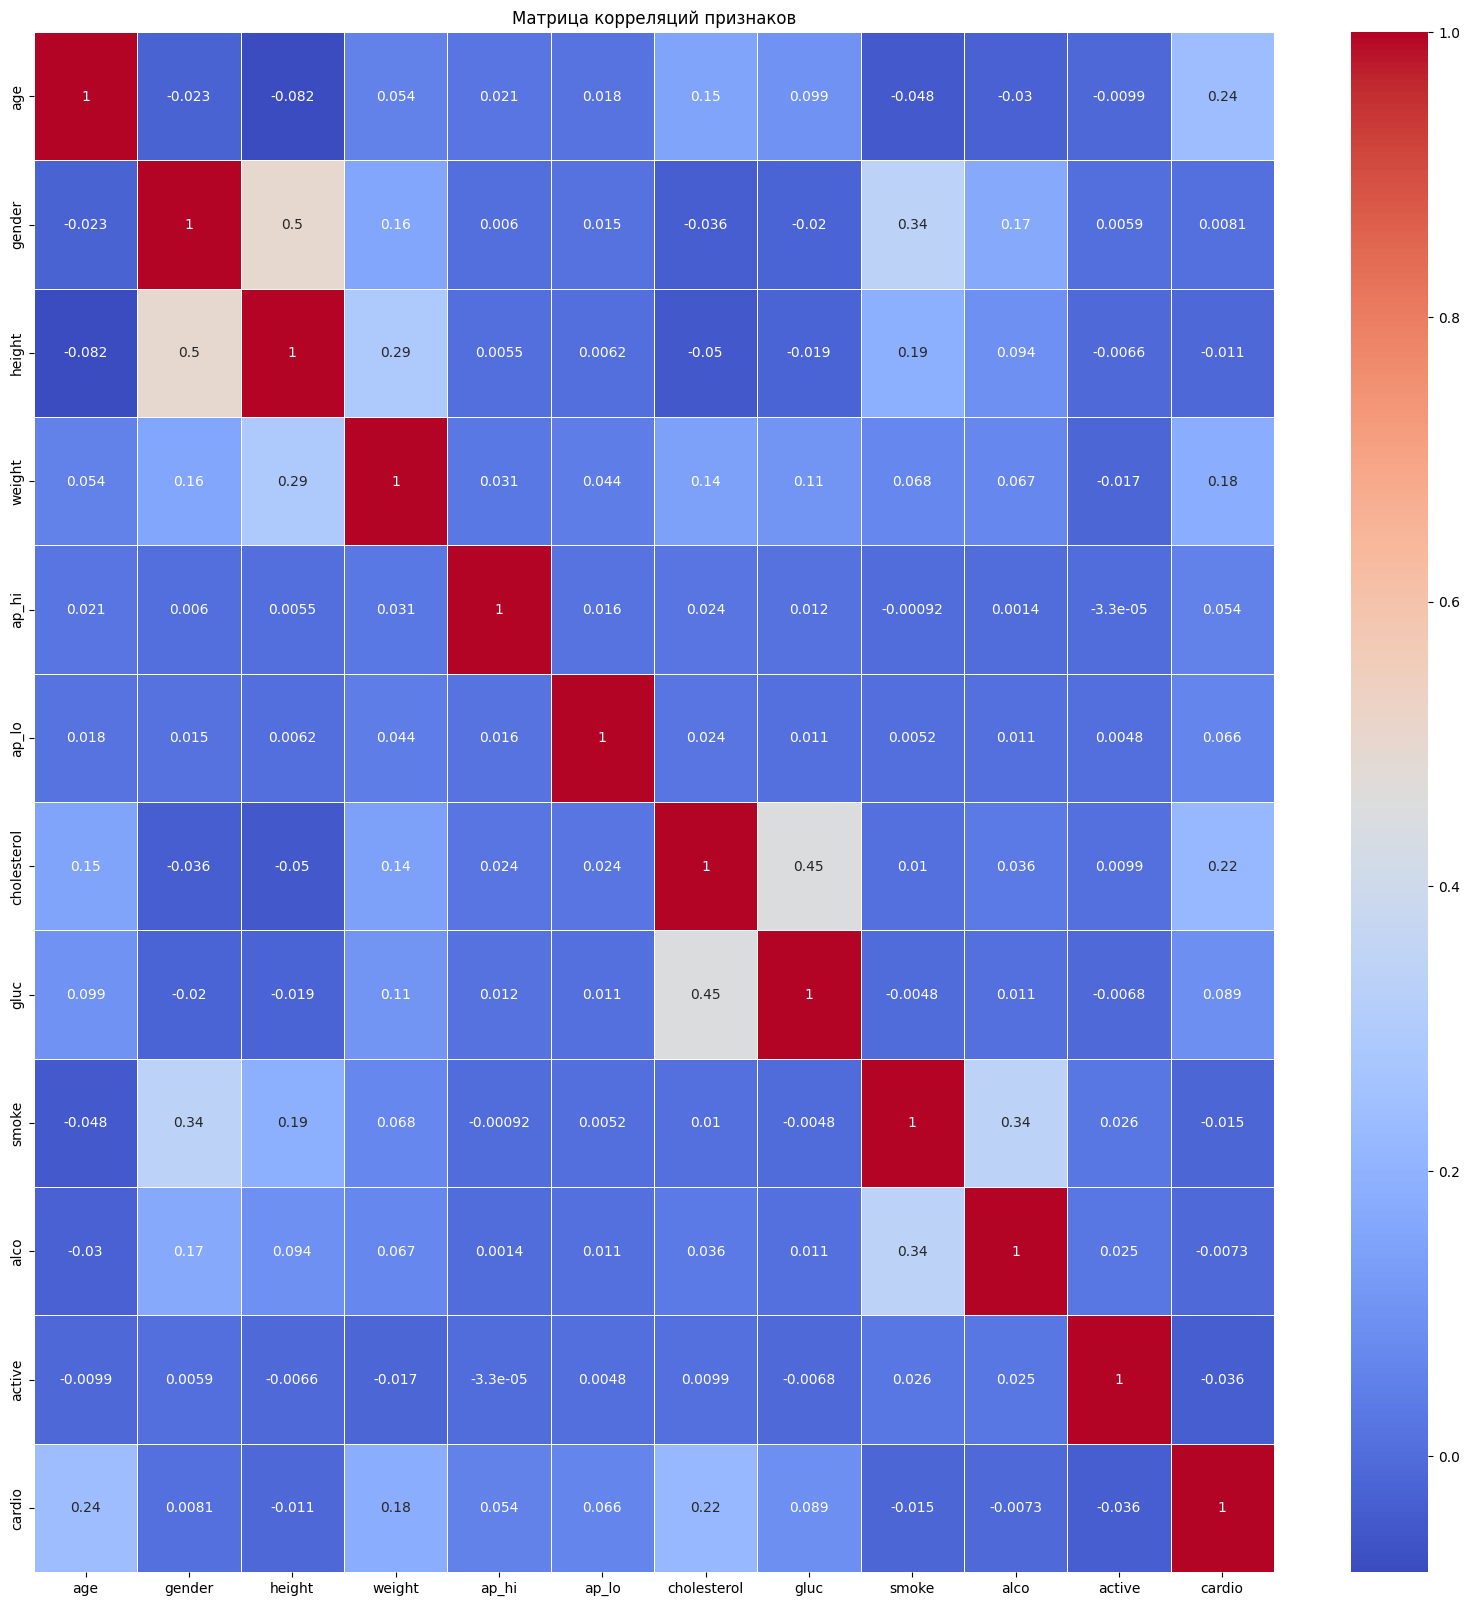

In [31]:
# Теперь проверьте мультиколлинеарность с помощью матрицы корреляций.
plt.figure(figsize=(20, 20))
sns.heatmap(cvd_1.corr(), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Матрица корреляций признаков')
plt.show()

In [ ]:
# выводы:
# по матрице корреляций видно, что нет сильной линейной зависимости между признаками, что подтверждает результаты проверки на мультиколлинеарность.
# больше всего коррелирует с целевой переменной 'cardio' (это наша целевая переменная) возраст 'age' 0.24 , уровень холестерина 'cholesterol' 0.22 и вес 'weight' 0.18,
# что может указывать на их важность для модели.

## Задание 3. Стандартизация (15 баллов)

Разделите данные на два массива: в переменную **Х** запишите массив признаков, а в переменную **y** - целевую переменную (cardio). Стандартизируйте массив признаков без использования готовых функций для стандартизации.

In [ ]:
X = cvd_1.drop(columns=['cardio'])
y = cvd_1['cardio']
num_cols = ['age', 'height', 'weight', 'ap_hi', 'ap_lo']
X[num_cols] = (X[num_cols] - X[num_cols].mean()) / X[num_cols].std()

Вычислите длину всех векторов - признаков. Прокомментируйте результат.

In [ ]:
vector_lengths = np.linalg.norm(X, axis=1)
print("Длина векторов признаков:", vector_lengths)
# что бы посмотреть все длины векторов признаков поместим их в датафрейм
vector_lengths_df = pd.DataFrame({'vector_length': vector_lengths})
display(vector_lengths_df.describe())

Длина векторов признаков: [2.85103258 3.70136048 3.40443952 ... 4.98690167 2.73891863 2.77399636]


,vector_length
count,70000.000000
mean,3.149151
std,1.496633
min,1.733967
25%,2.505357
50%,2.957975
75%,3.529185
max,103.201665


In [ ]:
# Вывод: После стандартизации признаки имеют сопоставимый масштаб, однако длины векторов различаются из-за различий в распределении значений и дисперсии признаков.


## Задание 4. Решение задачи классификации. (20 баллов)

**4.1** Теперь приступим непосредственно к решению задачи классификации. Обучите наивный байесовский классификатор. Предварительно выберите один из его видов: поясните свой выбор.

In [ ]:
from sklearn.naive_bayes import GaussianNB

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

gnb = GaussianNB()
gnb.fit(X_train, y_train)
y_pred = gnb.predict(X_test)

accuracy_gnb = metrics.accuracy_score(y_test, y_pred)
print("Точность наивного байесовского классификатора:", accuracy_gnb)

Accuracy GaussianNB: 0.5932857142857143


In [10]:
# Я выбрал гауссовский наивный байесовский классификатор, так как он хорошо работает с непрерывными признаками и предполагает, что они имеют нормальное распределение.
# точность 0.59 может быть не очень высокой, что может указывать на то, что модель не полностью захватывает сложные зависимости в данных.

**4.2** Оцените полученное качество и проинтерпретируйте полученный результат. Не забудьте разделить выборку на обучающую и тестовую части.

In [36]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
gnb = GaussianNB()
gnb.fit(X_train, y_train)
y_pred_gnb_test = gnb.predict(X_test)
accuracy_gnb_test = metrics.accuracy_score(y_test, y_pred_gnb_test)
print("Точность наивного байесовского классификатора на тестовой выборке:", accuracy_gnb_test)

Точность наивного байесовского классификатора на тестовой выборке: 0.5932857142857143


In [12]:
# ваш комментарий

## Задание 5: Решающее дерево (25 баллов)

Теперь решите задачу классификации с помощью обучающего дерева.

**5.1** Обучите дерево, не задавая никакие гиперпараметры. Выведите получившиеся гиперпараметры. Какое получилось качество? Сравните результат с предыдущей моделью.

In [38]:
from sklearn.tree import DecisionTreeClassifier

dtc = DecisionTreeClassifier(random_state=42)
dtc.fit(X_train, y_train)
y_pred = dtc.predict(X_test)

accuracy_dtc = metrics.accuracy_score(y_test, y_pred)
print("Точность дерева решений на тестовой выборке:", accuracy_dtc)
print("Гиперпараметры дерева решений:", dtc.get_params())


Точность дерева решений на тестовой выборке: 0.6270714285714286
Гиперпараметры дерева решений: {'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': 42, 'splitter': 'best'}


In [ ]:
# Сравните результат с предыдущей моделью. результат показывает, что точность дерева решений на тестовой выборке может быть выше, 
# чем у наивного байесовского классификатора, что может указывать на то, что дерево решений лучше захватывает сложные зависимости в данных.

**5.2** Подберите оптимальные гиперпараметры с помощью перебора по сетке. Обучите дерево с оптимальными гиперпараметрами. Изменилось ли качество?

In [50]:
# Подберите оптимальные гиперпараметры с помощью перебора по сетке. Обучите дерево с оптимальными гиперпараметрами. Изменилось ли качество?
from sklearn.model_selection import GridSearchCV

param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10]
}

grid_search = GridSearchCV(DecisionTreeClassifier(), param_grid, cv=5)
grid_search.fit(X_train, y_train)

print("Лучшие гиперпараметры:", grid_search.best_params_)
best_dtc = grid_search.best_estimator_
y_pred_best_dtc_test = best_dtc.predict(X_test)
accuracy_best_dtc_test = metrics.accuracy_score(y_test, y_pred_best_dtc_test)
print("Точность оптимизированного дерева решений на тестовой выборке:", accuracy_best_dtc_test)

Лучшие гиперпараметры: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_split': 10}
Точность оптимизированного дерева решений на тестовой выборке: 0.7311428571428571


In [ ]:
# оптимальные гиперпараметры которые улучшили точность модели это criterion='entropy', max_depth=10, min_samples_split=2, 
# что может указывать на то, что использование энтропии для разделения узлов и ограничение глубины дерева помогает улучшить обобщающую способность модели.

**5.3** Выведите важность признаков. Какие три признака самые важные? Прокомментируйте результат.

In [51]:
importances = best_dtc.feature_importances_
indices = np.argsort(importances)[::-1]
feature_names = X.columns
print("Важность признаков:")
for i in range(len(importances)):
    print(f"{feature_names[indices[i]]}: {importances[indices[i]]}")



Важность признаков:
ap_hi: 0.6548002714376558
age: 0.1596266925255011
cholesterol: 0.06660863544964975
weight: 0.04379104175959495
height: 0.028299557278749922
ap_lo: 0.01642690968598194
gluc: 0.010189525830854989
active: 0.008268043534785255
smoke: 0.005360121277777721
alco: 0.0034049678969474565
gender: 0.0032242333225011863


In [ ]:
# Три самых важных признака для модели дерева решений могут быть артериальное давление 'ap_hi', возраст 'age' и уровень холестерина 'cholesterol',
# что может указывать на их значимость для предсказания сердечно-сосудистых заболеваний.

## Задание 6: Случайный лес и градиентный бустинг (20 баллов)

Осталось применить ансамблевые методы!

**6.1** Используйте случайный лес: без настройки и с подробом гиперпараметров по сетке. Какое качество получается в ситуации оптимальных гиперпараметров? Какие признаки самые важные? Сравнение результат с простым решающим деревом.

In [27]:
# Используйте случайный лес: без настройки и с подробом гиперпараметров по сетке. 
# Какое качество получается в ситуации оптимальных гиперпараметров? Какие признаки самые важные? Сравнение результат с простым решающим деревом.
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
y_pred_rf_test = rf.predict(X_test)
accuracy_rf_test = metrics.accuracy_score(y_test, y_pred_rf_test)
print("Точность случайного леса на тестовой выборке:", accuracy_rf_test)    

#  теперрь подберем оптимальные гиперпараметры для случайного леса
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}
grid_search_rf = GridSearchCV(RandomForestClassifier(random_state=42), param_grid_rf, cv=5)
grid_search_rf.fit(X_train, y_train)
print("Лучшие гиперпараметры для случайного леса:", grid_search_rf.best_params_)
best_rf = grid_search_rf.best_estimator_
y_pred_best_rf_test = best_rf.predict(X_test)
accuracy_best_rf_test = metrics.accuracy_score(y_test, y_pred_best_rf_test)
print("Точность оптимизированного случайного леса на тестовой выборке:", accuracy_best_rf_test)

Точность случайного леса на тестовой выборке: 0.726
Лучшие гиперпараметры для случайного леса: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}
Точность оптимизированного случайного леса на тестовой выборке: 0.7386428571428572


In [ ]:
# Точность случайного леса на тестовой выборке: 0.726
# Лучшие гиперпараметры для случайного леса: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}
# Точность оптимизированного случайного леса на тестовой выборке: 0.7386428571428572

**6.2** Аналогичные операции реализуйте для градиентного бустинга. Попробуйте хотя бы две разных реализации градиентного бустинга. Сравните итоговое качество со случайным деревом.

In [ ]:
# сделаем градиентный бустинг без настройки
from sklearn.ensemble import GradientBoostingClassifier
gbc = GradientBoostingClassifier(random_state=42)
gbc.fit(X_train, y_train)
y_pred_gbc_test = gbc.predict(X_test)
accuracy_gbc_test = metrics.accuracy_score(y_test, y_pred_gbc_test)
print("Точность градиентного бустинга на тестовой выборке:", accuracy_gbc_test)

# сделаем градиентный бустинг с подбором гиперпараметров
param_grid_gbc = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1],
    'max_depth': [3, 5]
}
grid_search_gbc = GridSearchCV(GradientBoostingClassifier(random_state=42), param_grid_gbc, cv=5)
grid_search_gbc.fit(X_train, y_train)
print("Лучшие гиперпараметры для градиентного бустинга:", grid_search_gbc.best_params_)
best_gbc = grid_search_gbc.best_estimator_
y_pred_best_gbc_test = best_gbc.predict(X_test)
accuracy_best_gbc_test = metrics.accuracy_score(y_test, y_pred_best_gbc_test)
print("Точность оптимизированного градиентного бустинга на тестовой выборке:", accuracy_best_gbc_test)


Точность градиентного бустинга на тестовой выборке: 0.7368571428571429
Лучшие гиперпараметры для градиентного бустинга: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
Точность оптимизированного градиентного бустинга на тестовой выборке: 0.7368571428571429


In [ ]:
# Точность градиентного бустинга на тестовой выборке: 0.7368571428571429
# Лучшие гиперпараметры для градиентного бустинга: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
# Точность оптимизированного градиентного бустинга на тестовой выборке: 0.7368571428571429

In [ ]:
#  Точность оптимизированного случайного леса на тестовой выборке: 0.7386428571428572 что сравнимо с Точностью оптимизированного градиентного бустинга на тестовой выборке: 0.7368571428571429
